In [ ]:
!pip install "torchmetrics[detection]" scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.7 MB/s eta 0:00:00


In [ ]:
import os
from pathlib import Path

import numpy as np
import torch
import torchvision
from PIL import Image
import xml.etree.ElementTree as ET
import scipy.io as sio

from sklearn.model_selection import train_test_split
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models import ResNet50_Weights
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch.manual_seed(0)
np.random.seed(0)


Using device: cuda
torch: 2.9.0+cu126
torchvision: 0.24.0+cu126


In [ ]:
!mkdir -p /content/data/stanford_dogs
%cd /content/data/stanford_dogs

!wget -q http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
!wget -q http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar
!wget -q http://vision.stanford.edu/aditya86/ImageNetDogs/lists.tar

!tar -xf images.tar
!tar -xf annotation.tar
!tar -xf lists.tar



/content/data/stanford_dogs


In [ ]:
root = Path("/content/data/stanford_dogs")
images_dir = root / "Images"
ann_dir    = root / "Annotation"

def load_split(mat_name="train_list.mat"):
    mat = sio.loadmat(root / mat_name)
    file_list = [x[0][0] for x in mat["file_list"]]
    ann_list  = [x[0][0] for x in mat["annotation_list"]]
    labels    = [int(x[0]) for x in mat["labels"]]
    return file_list, ann_list, labels

train_files, train_anns, train_labels = load_split("train_list.mat")
test_files,  test_anns,  test_labels  = load_split("test_list.mat")

print("Train files:", len(train_files))
print("Test files:", len(test_files))

# synsety from z train + test
synsets = sorted({f.split('/')[0] for f in train_files + test_files})
class_names = ["__background__"] + synsets
synset_to_idx = {syn: i + 1 for i, syn in enumerate(synsets)}
num_classes = len(class_names)  # 121

print("Num classes (incl. background):", num_classes)

# stratified split train -> train_idx, val_idx
indices = np.arange(len(train_files))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=0,
    stratify=np.array(train_labels)
)

print("Train idx:", len(train_idx))
print("Val idx:", len(val_idx))


Train files: 12000
Test files: 8580
Num classes (incl. background): 121
Train idx: 9600
Val idx: 2400


In [ ]:
images_dir = root / "Images"
ann_dir    = root / "Annotation"

def apply_transforms(img, boxes, train_mode=True):
    img = F.to_tensor(img)
    return img, boxes

def load_image_and_target(abs_index, split="train", train_mode=True):
    """
    abs_index: index into train_files or test_files (NOT into train_idx/val_idx)
    split: 'train'/'val'/'test'
    train_mode: whether to apply augmentation (flip)
    """
    if split in ["train", "val"]:
        files = train_files
        anns  = train_anns
    elif split == "test":
        files = test_files
        anns  = test_anns
    else:
        raise ValueError("split must be 'train', 'val', or 'test'")

    img_rel = files[abs_index]          # e.g. 'n02085620-Chihuahua/n02085620_10074.jpg'
    ann_rel = anns[abs_index]           # e.g. 'n02085620-Chihuahua/n02085620_10074'

    img_path = images_dir / img_rel
    xml_path = ann_dir / ann_rel

    img = Image.open(img_path).convert("RGB")

    # parse bounding boxes from XML
    tree = ET.parse(xml_path)
    root_xml = tree.getroot()
    bboxes = []
    for obj in root_xml.findall("object"):
        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)
        bboxes.append([xmin, ymin, xmax, ymax])

    boxes = torch.tensor(bboxes, dtype=torch.float32)

    # class id from synset
    synset = img_rel.split('/')[0]
    class_id = synset_to_idx[synset]
    labels = torch.full((boxes.shape[0],), class_id, dtype=torch.int64)

    # transofrm to tensor
    img, boxes = apply_transforms(img, boxes, train_mode=train_mode)

    area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)
    image_id = torch.tensor([abs_index])

    target = {
        "boxes": boxes,
        "labels": labels,
        "image_id": image_id,
        "area": area,
        "iscrowd": iscrowd,
    }

    return img, target

img, target = load_image_and_target(int(train_idx[0]), split="train", train_mode=True)
print("Image shape:", img.shape)
print("Target:", target)


Image shape: torch.Size([3, 375, 500])
Target: {'boxes': tensor([[  0.,  36., 266., 374.]]), 'labels': tensor([110]), 'image_id': tensor([10943]), 'area': tensor([89908.]), 'iscrowd': tensor([0])}


In [ ]:
def train_one_epoch(model, optimizer, train_idx, batch_size, device, verbose=True):
    model.train()
    train_losses = []

    perm = np.random.permutation(train_idx)

    for i in range(0, len(perm), batch_size):
        batch_abs_indices = perm[i:i + batch_size]

        images = []
        targets = []
        for abs_idx in batch_abs_indices:
            img, target = load_image_and_target(int(abs_idx), split="train", train_mode=True)
            images.append(img.to(device))
            targets.append({k: v.to(device) for k, v in target.items()})

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        if not torch.isfinite(loss):
            print("Non-finite loss, skipping batch.")
            print("Loss dict:", loss_dict)
            print("Batch indices:", batch_abs_indices)
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())

        if verbose and (i // batch_size + 1) % 50 == 0:
            print(f"Train iter {(i // batch_size) + 1}, loss = {loss.item():.4f}")

    return float(np.mean(train_losses))


def evaluate_map_on_indices(model, indices, split, device):
    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_thresholds=None,
        class_metrics=False
    )

    model.eval()
    metric.reset()

    with torch.no_grad():
        for abs_idx in indices:
            img, target = load_image_and_target(int(abs_idx), split=split, train_mode=False)

            outputs = model([img.to(device)])[0]

            preds_tm = [{
                "boxes":  outputs["boxes"].cpu(),
                "scores": outputs["scores"].cpu(),
                # posun 1..120 na 0..119
                "labels": (outputs["labels"] - 1).cpu(),
            }]

            target_tm = [{
                "boxes":  target["boxes"].cpu(),
                "labels": (target["labels"] - 1).cpu(),
            }]

            metric.update(preds_tm, target_tm)

    results = metric.compute()
    return {
        "map":    results["map"].item(),
        "map50":  results["map_50"].item(),
        "map75":  results["map_75"].item(),
    }


In [ ]:
backbone_weights = ResNet50_Weights.IMAGENET1K_V1

model = retinanet_resnet50_fpn(
    weights=None,
    weights_backbone=backbone_weights,
    num_classes=num_classes,
)

model.transform.min_size = (400,)   # namiesto 800
model.transform.max_size = 667      # namiesto 1333

model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0005,
)

print("Model ready.")


Model ready.


In [ ]:
num_epochs = 33
batch_size = 12

epoch_train_losses = []
epoch_val_map50 = []

for e in range(num_epochs):
    print(f"\n===== Epoch {e} =====")
    train_loss = train_one_epoch(
        model,
        optimizer,
        train_idx=train_idx,
        batch_size=batch_size,
        device=device,
        verbose=True,
    )
    epoch_train_losses.append(train_loss)
    print(f"Train loss: {train_loss:.4f}")

    val_metrics = evaluate_map_on_indices(
        model,
        indices=val_idx,
        split="train",
        device=device,
    )
    epoch_val_map50.append(val_metrics["map50"])
    print(
        f"Val mAP: {val_metrics['map']:.3f}, "
        f"mAP50: {val_metrics['map50']:.3f}, "
        f"mAP75: {val_metrics['map75']:.3f}"
    )

    torch.save(model.state_dict(), f"/content/retinanet_epoch{e:03d}.pth")
    print(f"Saved checkpoint: retinanet_epoch{e:03d}.pth")



===== Epoch 0 =====
Train iter 50, loss = 1.9603
Train iter 100, loss = 1.9096
Train iter 150, loss = 1.8868
Train iter 200, loss = 1.7915
Train iter 250, loss = 1.7842
Train iter 300, loss = 1.8715
Train iter 350, loss = 1.7399
Train iter 400, loss = 1.7099
Train iter 450, loss = 1.7428
Train iter 500, loss = 1.7190
Train iter 550, loss = 1.7232
Train iter 600, loss = 1.6862
Train iter 650, loss = 1.6612
Train iter 700, loss = 1.6787
Train iter 750, loss = 1.8156
Train iter 800, loss = 1.6265
Train loss: 1.7663
Val mAP: 0.000, mAP50: 0.000, mAP75: 0.000
Saved checkpoint: retinanet_epoch000.pth

===== Epoch 1 =====
Train iter 50, loss = 1.7213
Train iter 100, loss = 1.6420
Train iter 150, loss = 1.7177
Train iter 200, loss = 1.6623
Train iter 250, loss = 1.6089
Train iter 300, loss = 1.6160
Train iter 350, loss = 1.7135
Train iter 400, loss = 1.6439
Train iter 450, loss = 1.6461
Train iter 500, loss = 1.5451
Train iter 550, loss = 1.6010
Train iter 600, loss = 1.6163
Train iter 650, l

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Val mAP: 0.006, mAP50: 0.010, mAP75: 0.006
Saved checkpoint: retinanet_epoch002.pth

===== Epoch 3 =====
Train iter 50, loss = 1.3499
Train iter 100, loss = 1.4392
Train iter 150, loss = 1.3202
Train iter 200, loss = 1.2908
Train iter 250, loss = 1.2756
Train iter 300, loss = 1.2732
Train iter 350, loss = 1.2471
Train iter 400, loss = 1.2897
Train iter 450, loss = 1.1640
Train iter 500, loss = 1.2325
Train iter 550, loss = 1.2883
Train iter 600, loss = 1.2694
Train iter 650, loss = 1.2505
Train iter 700, loss = 1.2975
Train iter 750, loss = 1.3080
Train iter 800, loss = 1.3071
Train loss: 1.2945
Val mAP: 0.006, mAP50: 0.011, mAP75: 0.007
Saved checkpoint: retinanet_epoch003.pth

===== Epoch 4 =====
Train iter 50, loss = 1.1785
Train iter 100, loss = 1.2188
Train iter 150, loss = 1.2105
Train iter 200, loss = 1.3187
Train iter 250, loss = 1.1763
Train iter 300, loss = 1.2767
Train iter 350, loss = 1.2198
Train iter 400, loss = 1.2214
Train iter 450, loss = 1.1571
Train iter 500, loss = 

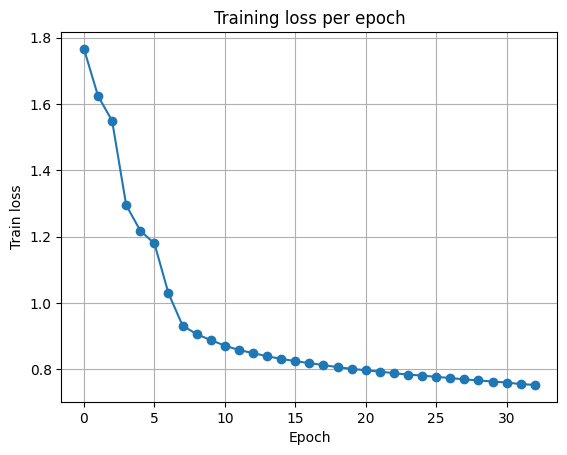

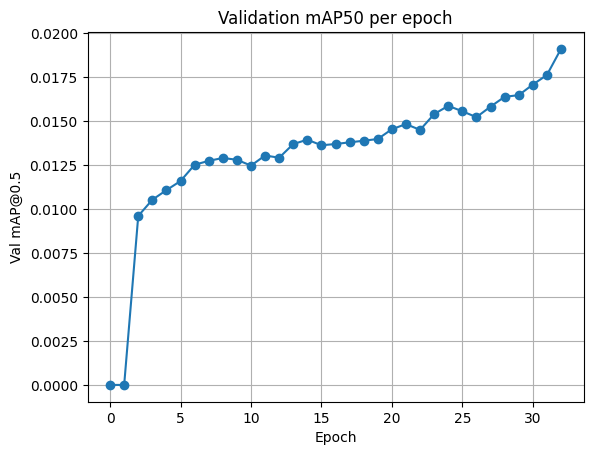

In [ ]:
epochs = np.arange(num_epochs)

plt.figure()
plt.plot(epochs, epoch_train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Training loss per epoch")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, epoch_val_map50, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Val mAP@0.5")
plt.title("Validation mAP50 per epoch")
plt.grid(True)
plt.show()


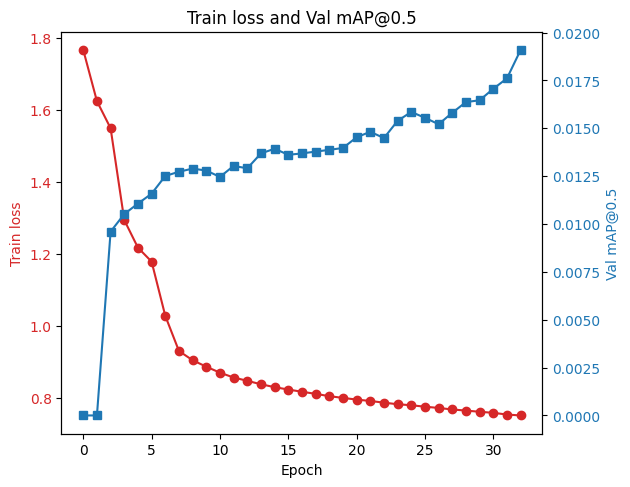

In [ ]:
fig, ax1 = plt.subplots()

color1 = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train loss', color=color1)
ax1.plot(epochs, epoch_train_losses, marker='o', color=color1, label='Train loss')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Val mAP@0.5', color=color2)
ax2.plot(epochs, epoch_val_map50, marker='s', color=color2, label='Val mAP@0.5')
ax2.tick_params(axis='y', labelcolor=color2)

fig.tight_layout()
plt.title("Train loss and Val mAP@0.5")
plt.show()


In [ ]:
best_epoch = int(np.argmax(epoch_val_map50))
print("Best epoch by val mAP@0.5:", best_epoch)

best_ckpt_path = f"/content/retinanet_epoch{best_epoch:03d}.pth"
print("Loading best checkpoint:", best_ckpt_path)

best_model = retinanet_resnet50_fpn(
    weights=None,
    weights_backbone=backbone_weights,
    num_classes=num_classes,
)
best_model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
best_model.to(device)

test_indices = np.arange(len(test_files))

test_metrics = evaluate_map_on_indices(
    best_model,
    indices=test_indices,
    split="test",
    device=device,
)

print("\n=== TEST RESULTS ===")
print("Test mAP (0.5:0.95):", test_metrics["map"])
print("Test mAP@0.5:      ", test_metrics["map50"])
print("Test mAP@0.75:     ", test_metrics["map75"])


Best epoch by val mAP@0.5: 32
Loading best checkpoint: /content/retinanet_epoch032.pth

=== TEST RESULTS ===
Test mAP (0.5:0.95): 0.006200861651450396
Test mAP@0.5:       0.010356524959206581
Test mAP@0.75:      0.0065924846567213535
